# Principal Component Analysis with Cancer Data

In [191]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [192]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done
cancer_data = pd.read_csv("breast-cancer-wisconsin-data.csv")
cancer_data.head(10)


,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [193]:
cancer_data.dtypes
#X = pca_cancer_data.drop(labels= "Class" , axis = 1)

ID                              int64
ClumpThickness                  int64
Cell Size                       int64
Cell Shape                      int64
Marginal Adhesion               int64
Single Epithelial Cell Size     int64
Bare Nuclei                    object
Normal Nucleoli                 int64
Bland Chromatin                 int64
Mitoses                         int64
Class                           int64
dtype: object

In [194]:
cancer_data.shape

(699, 11)

# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [195]:
print("checking id any missing data")
cancer_data.isna().any()

checking id any missing data


ID                             False
ClumpThickness                 False
Cell Size                      False
Cell Shape                     False
Marginal Adhesion              False
Single Epithelial Cell Size    False
Bare Nuclei                    False
Normal Nucleoli                False
Bland Chromatin                False
Mitoses                        False
Class                          False
dtype: bool

In [196]:
cancer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [197]:
cancer_data.describe()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [198]:
duplicateRowsDF = cancer_data[cancer_data.duplicated()]
print(duplicateRowsDF.shape)
cancer_data.drop_duplicates(keep=False, inplace=True)
#duplicateRowsDF = Cancerdata_DF[Cancerdata_DF.duplicated()]
#print(duplicateRowsDF.shape)


(8, 11)


In [199]:
cancer_data.shape

(683, 11)

In [200]:
cancer_data= cancer_data.drop(labels= "ID" , axis = 1)

In [201]:
cancer_data.dtypes

ClumpThickness                  int64
Cell Size                       int64
Cell Shape                      int64
Marginal Adhesion               int64
Single Epithelial Cell Size     int64
Bare Nuclei                    object
Normal Nucleoli                 int64
Bland Chromatin                 int64
Mitoses                         int64
Class                           int64
dtype: object

In [202]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column
cancer_df=cancer_data=='?'
cancer_df
print("column having values ? ",cancer_df.any())


column having values ?  ClumpThickness                 False
Cell Size                      False
Cell Shape                     False
Marginal Adhesion              False
Single Epithelial Cell Size    False
Bare Nuclei                     True
Normal Nucleoli                False
Bland Chromatin                False
Mitoses                        False
Class                          False
dtype: bool


In [203]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?
df2=cancer_data[cancer_data["Bare Nuclei"]=='?']
#print("count of rows having ? ",cancer_df["Bare Nuclei"].any().count())
df2.shape

(16, 10)

In [204]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values
cancer_data=cancer_data.replace('?',np.nan)
cancer_data.isna().any()
#cancer_data["Bare Nuclei"]=cancer_data.fillna()
#cancer_df[cancer_df["Bare Nuclei"]=='?']

median=cancer_df["Bare Nuclei"].median()
cancer_data.fillna(median,inplace=True)
cancer_data.describe()


,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.436310,3.125915,3.194729,2.843338,3.206442,3.433382,2.898975,1.597365,2.688141
std,2.815953,3.030919,2.947513,2.877824,2.184956,2.446411,3.079120,1.731321,0.950825
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [205]:

#(cancer_data["Bare Nuclei"]==median).any()
cancer_data.isna().any()


ClumpThickness                 False
Cell Size                      False
Cell Shape                     False
Marginal Adhesion              False
Single Epithelial Cell Size    False
Bare Nuclei                    False
Normal Nucleoli                False
Bland Chromatin                False
Mitoses                        False
Class                          False
dtype: bool

In [206]:
cancer_data.shape

(683, 10)

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [207]:
cancer_data.corr()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ClumpThickness,1.000000,0.641744,0.652925,0.489557,0.512964,0.563792,0.535582,0.350676,0.717911
Cell Size,0.641744,1.000000,0.903901,0.720908,0.742223,0.763451,0.731788,0.461504,0.817538
Cell Shape,0.652925,0.903901,1.000000,0.699192,0.708879,0.741057,0.730159,0.442361,0.816426
Marginal Adhesion,0.489557,0.720908,0.699192,1.000000,0.617739,0.672991,0.601522,0.416689,0.706065
Single Epithelial Cell Size,0.512964,0.742223,0.708879,0.617739,1.000000,0.625126,0.639503,0.486362,0.679651
Normal Nucleoli,0.563792,0.763451,0.741057,0.672991,0.625126,1.000000,0.672310,0.343478,0.756623
Bland Chromatin,0.535582,0.731788,0.730159,0.601522,0.639503,0.672310,1.000000,0.426937,0.718929
Mitoses,0.350676,0.461504,0.442361,0.416689,0.486362,0.343478,0.426937,1.000000,0.425083
Class,0.717911,0.817538,0.816426,0.706065,0.679651,0.756623,0.718929,0.425083,1.000000


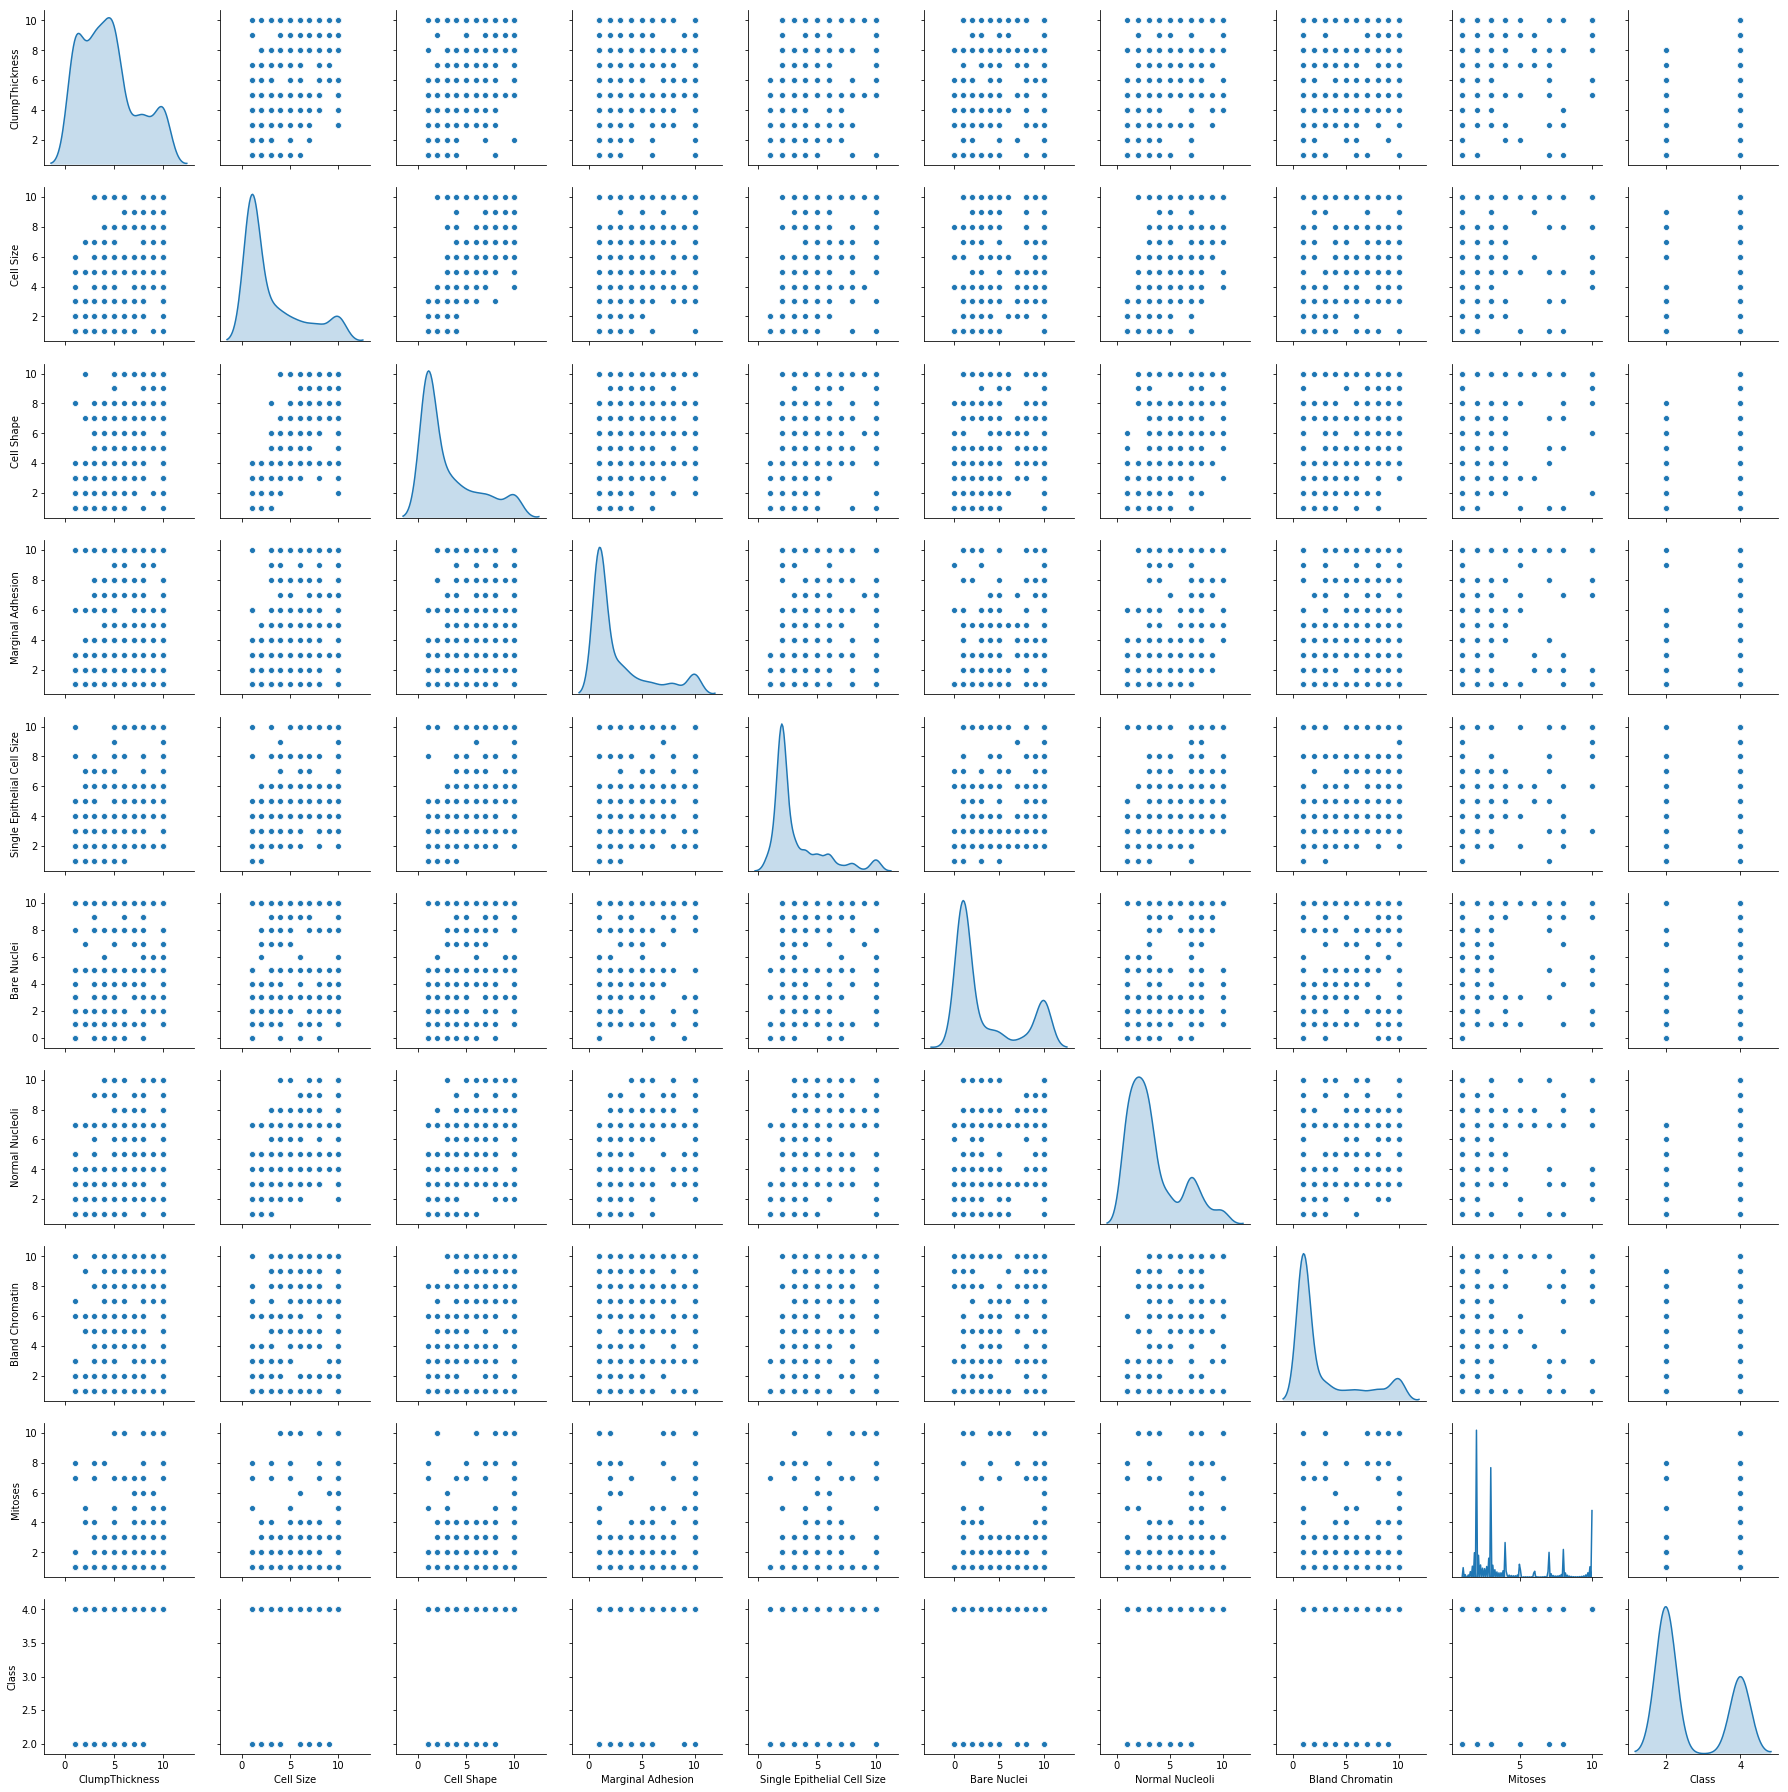

In [209]:
# Check for correlation of variable
cancer_data["Bare Nuclei"] = pd.to_numeric(cancer_data["Bare Nuclei"])

sns.pairplot(cancer_data, diag_kind='kde')

In [211]:
# converting the Bare Nuclei column from object type to float
cancer_data['Bare Nuclei'] = cancer_data['Bare Nuclei'].astype('float64')
cancer_data.dtypes

ClumpThickness                   int64
Cell Size                        int64
Cell Shape                       int64
Marginal Adhesion                int64
Single Epithelial Cell Size      int64
Bare Nuclei                    float64
Normal Nucleoli                  int64
Bland Chromatin                  int64
Mitoses                          int64
Class                            int64
dtype: object

In [212]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [213]:
#Let us check for pair plots

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [214]:
# We could see most of the outliers are now removed.

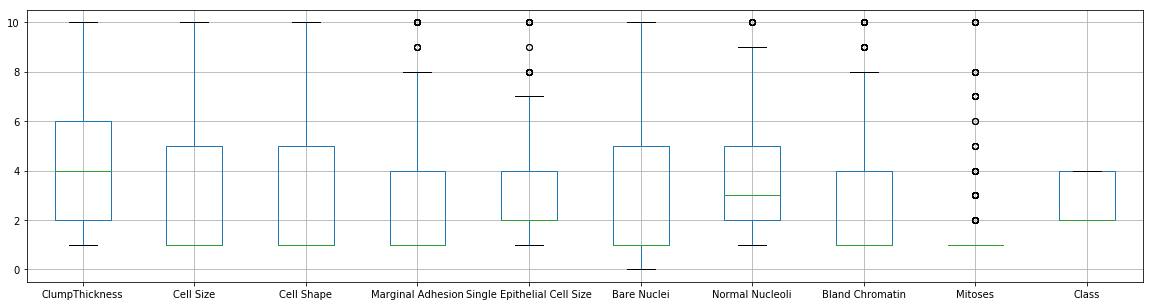

In [215]:
boxplot=cancer_data.boxplot(figsize=(20,5))

In [216]:
q1, q3= np.percentile(cancer_data,[25,75])
iqr = q3 - q1
lower_bound = q1 -(1.5 * iqr) 
upper_bound = q3 +(1.5 * iqr) 

In [217]:
#cancer_data["Marginal Adhesion"] = np.where(cancer_data["Marginal Adhesion"] >5 , 5,cancer_data["Marginal Adhesion"])
#cancer_data["Single Epithelial Cell Size"] = np.where(cancer_data["Single Epithelial Cell Size"] >upper_bound , median,cancer_data["Single Epithelial Cell Size"])
#cancer_data["Normal Nucleoli"] = np.where(cancer_data["Normal Nucleoli"] >upper_bound , median,cancer_data["Normal Nucleoli"])
#cancer_data["Bland Chromatin"] = np.where(cancer_data["Bland Chromatin"] >upper_bound , median,cancer_data["Bland Chromatin"])
#cancer_data["Mitoses"] = np.where(cancer_data["Mitoses"] >upper_bound , median,cancer_data["Mitoses"])


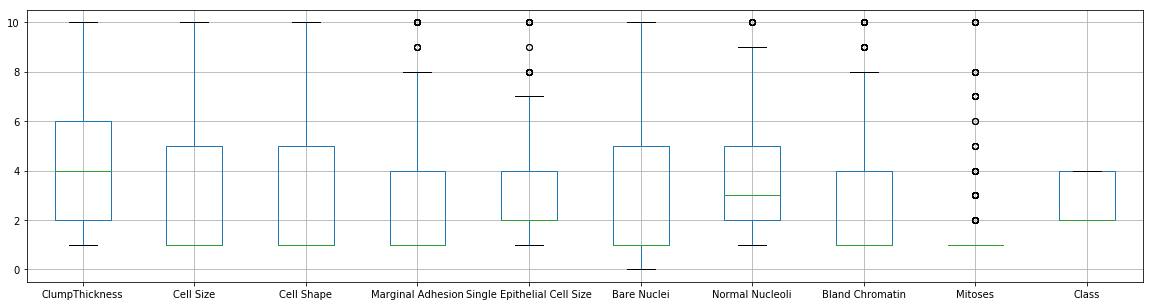

In [218]:
boxplot=cancer_data.boxplot(figsize=(20,5))

# Q6 Create a covariance matrix for identifying Principal components

In [219]:
# PCA
# Step 1 - Create covariance matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X=cancer_data.drop('Class',axis=1)
Y=cancer_data['Class']
sc = StandardScaler()
X_std =  sc.fit_transform(X)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)


Covariance Matrix 
%s [[1.00146628 0.64268541 0.65388211 0.49027485 0.5137159  0.5918955
  0.56461834 0.53636755 0.35119007]
 [0.64268541 1.00146628 0.90522601 0.72196486 0.74331134 0.68170095
  0.76457068 0.73286069 0.46218096]
 [0.65388211 0.90522601 1.00146628 0.70021741 0.7099183  0.69919832
  0.74214403 0.73122981 0.44300916]
 [0.49027485 0.72196486 0.70021741 1.00146628 0.61864498 0.67837517
  0.67397729 0.60240447 0.4172999 ]
 [0.5137159  0.74331134 0.7099183  0.61864498 1.00146628 0.57767184
  0.62604243 0.64044055 0.48707557]
 [0.5918955  0.68170095 0.69919832 0.67837517 0.57767184 1.00146628
  0.66937626 0.5802672  0.34459841]
 [0.56461834 0.76457068 0.74214403 0.67397729 0.62604243 0.66937626
  1.00146628 0.67329615 0.34398191]
 [0.53636755 0.73286069 0.73122981 0.60240447 0.64044055 0.5802672
  0.67329615 1.00146628 0.42756345]
 [0.35119007 0.46218096 0.44300916 0.4172999  0.48707557 0.34459841
  0.34398191 0.42756345 1.00146628]]


/Users/kumanish/anaconda3/lib/python3.7/site-packages/sklearn/preprocessing/data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
/Users/kumanish/anaconda3/lib/python3.7/site-packages/sklearn/base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


# Q7 Identify eigen values and eigen vector

In [220]:
# Step 2- Get eigen values and eigen vector

In [221]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-0.30139965 -0.15375204  0.8683756   0.00423371 -0.02907771 -0.06583088
  -0.30045868  0.1281634   0.1397997 ]
 [-0.38063844 -0.04782903 -0.05257692  0.73822721 -0.17811595 -0.09910515
   0.43274186  0.27501854  0.02520266]
 [-0.37684723 -0.08177757  0.00726999 -0.66297343 -0.16336446 -0.04530584
   0.5792116   0.20487958  0.07422734]
 [-0.33597083 -0.05537298 -0.35973246 -0.04421224  0.49740977 -0.00345896
  -0.32724939  0.36386127  0.51553821]
 [-0.33555375  0.18288156 -0.19928129 -0.06532821 -0.27609099 -0.75218581
  -0.29463792 -0.27468915 -0.07551057]
 [-0.33157365 -0.24504353  0.06094829  0.06600505  0.57400717  0.01419395
   0.23422531 -0.64557481 -0.14362172]
 [-0.34687741 -0.22973499 -0.17323192 -0.06584151 -0.03009598  0.26258663
  -0.31988273  0.26985096 -0.73996722]
 [-0.33717272  0.01683931 -0.14471488  0.02179141 -0.4907459   0.55871364
  -0.18288924 -0.40911641  0.33286116]
 [-0.22985998  0.90430373  0.13899556 -0.00893119  0.21418917  0.1915261
   0.

# Q8 Find variance and cumulative variance by each eigen vector

In [222]:
# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(5.9179455612413445, array([-0.30139965, -0.38063844, -0.37684723, -0.33597083, -0.33555375,
       -0.33157365, -0.34687741, -0.33717272, -0.22985998])), (0.7773972204780937, array([-0.15375204, -0.04782903, -0.08177757, -0.05537298,  0.18288156,
       -0.24504353, -0.22973499,  0.01683931,  0.90430373])), (0.5427709258578199, array([ 0.8683756 , -0.05257692,  0.00726999, -0.35973246, -0.19928129,
        0.06094829, -0.17323192, -0.14471488,  0.13899556])), (0.46834310937390167, array([-0.02907771, -0.17811595, -0.16336446,  0.49740977, -0.27609099,
        0.57400717, -0.03009598, -0.4907459 ,  0.21418917])), (0.36078320519373425, array([-0.06583088, -0.09910515, -0.04530584, -0.00345896, -0.75218581,
        0.01419395,  0.26258663,  0.55871364,  0.1915261 ])), (0.3049177279174333, array([ 0.1281634 ,  0.27501854,  0.20487958,  0.36386127, -0.27468915,
       -0.64557481,  0.26985096, -0.40911641,  0.03393438])), (0.28747808939673664, array([ 0.1397997 ,  0.02520266,  0.07422734,

In [223]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 9 entries as there are 9 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry 
# cumulative reaching almost 100%

In [224]:
var_explained

[0.6565867696057583,
 0.08625100119831786,
 0.060219582143327344,
 0.05196193274654318,
 0.04002833023297979,
 0.03383014323079381,
 0.031895242714913674,
 0.029021022373994915,
 0.010205975753370969]

In [225]:
cum_var_exp

array([0.65658677, 0.74283777, 0.80305735, 0.85501929, 0.89504762,
       0.92887776, 0.960773  , 0.98979402, 1.        ])

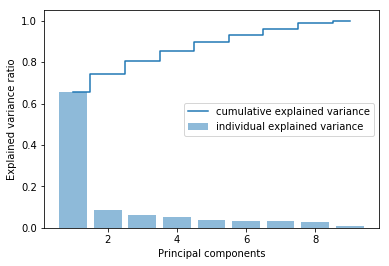

In [226]:
plt.bar(range(1,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [227]:
from sklearn.decomposition import PCA
X_centered = X - X.mean(axis=0)
pca = PCA(n_components=8)
pca.fit(X_centered)
X_pca = pca.transform(X_centered)
X_pca.shape

(683, 8)

# Q10 Find correlation between components and features

/Users/kumanish/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


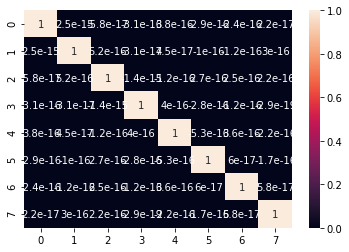

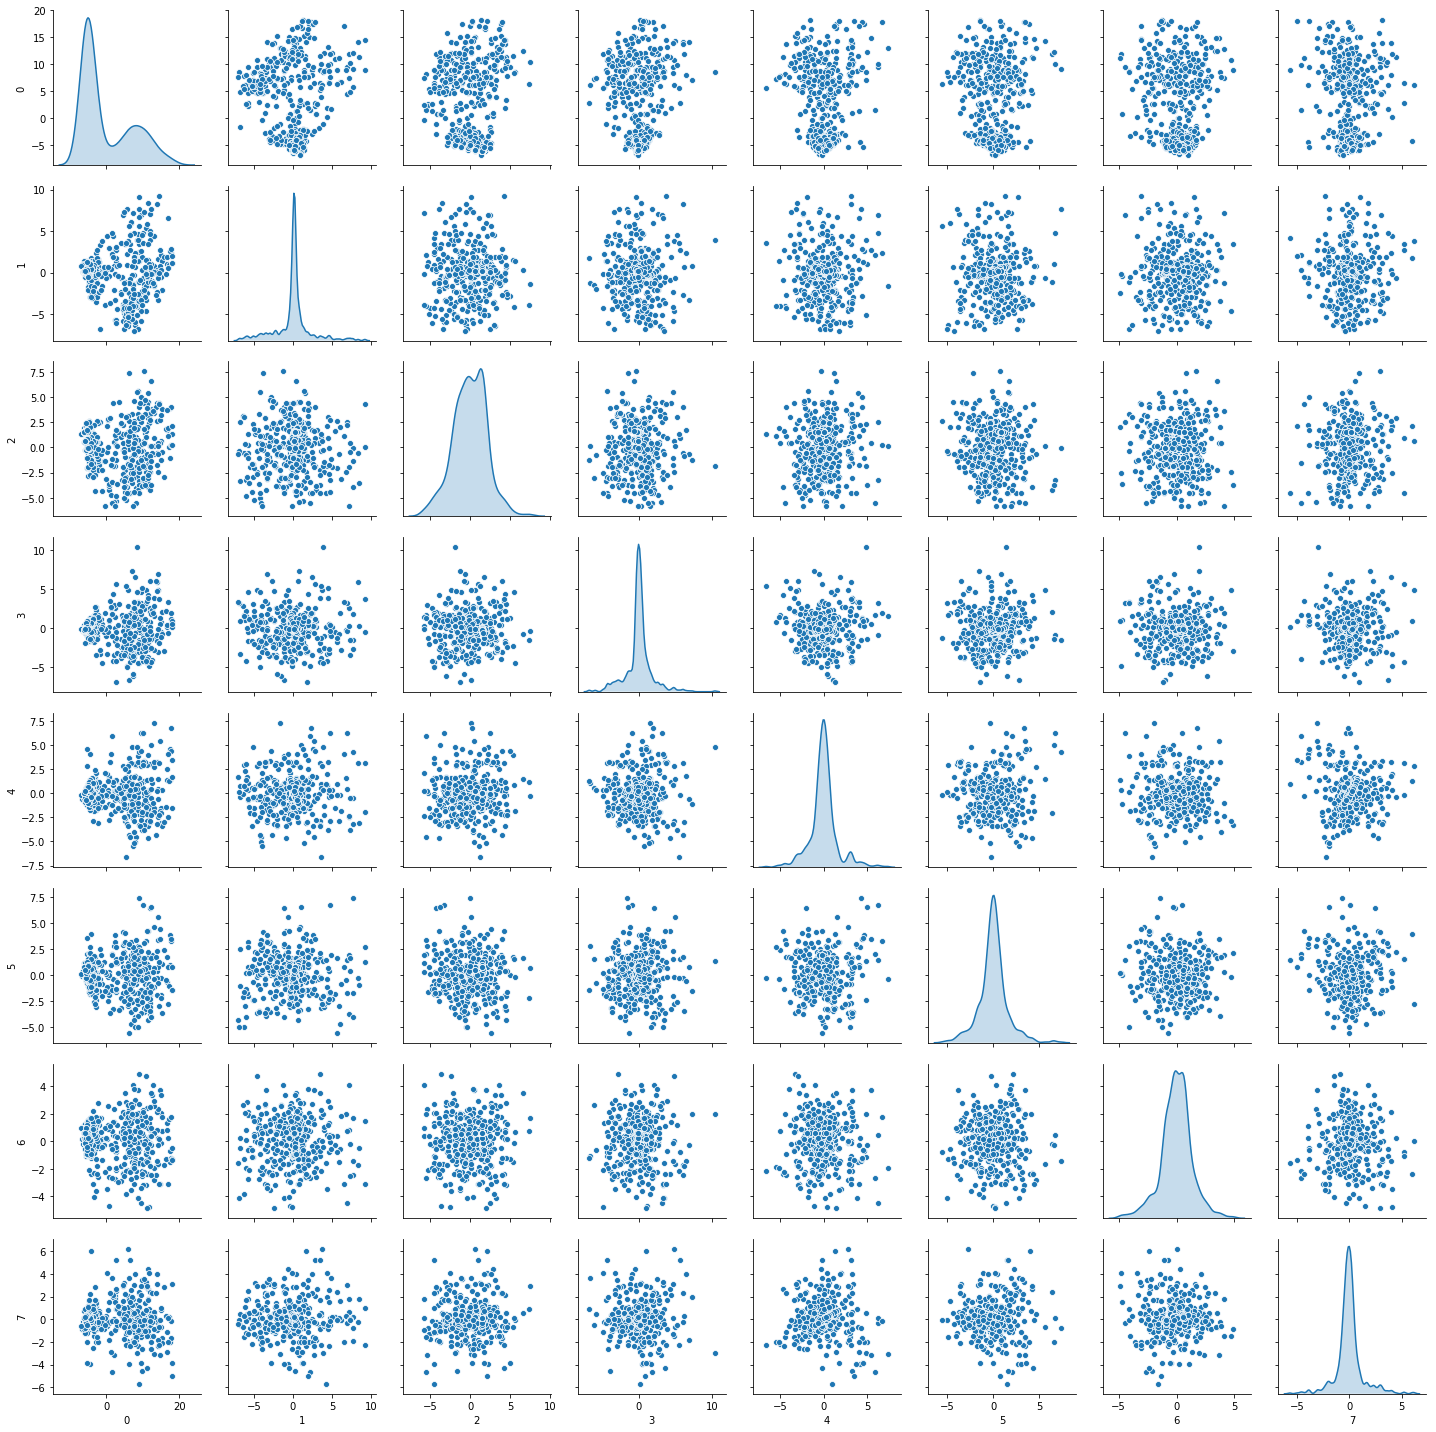

In [228]:
pca.components_
pca.explained_variance_
pca.explained_variance_ratio_
pca_new_df=pd.DataFrame(X_pca)
sns.heatmap(pca_new_df.corr(), annot=True)
sns.pairplot(pca_new_df, diag_kind='kde')